In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

spmv_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*spmv_128*.csv"))))
spmv_df["accelerator"] = "AscendSparse - Ascend910B4"

/scratch/gsorrentino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
spmv_df.head()

,benchname,operator,dtype,nnz,time_us,accelerator
0,conf5_4-8x8-05,spmv_128,fp16,1916928,305.56,AscendSparse - Ascend910B4
0,cant,spmv_128,fp16,4007383,435.89,AscendSparse - Ascend910B4
0,pdb1HYS,spmv_128,fp16,4344765,449.12,AscendSparse - Ascend910B4
0,rma10,spmv_128,fp16,2374001,372.43,AscendSparse - Ascend910B4
0,conf5_4-8x8-10,spmv_128,fp16,1916928,374.81,AscendSparse - Ascend910B4


In [3]:
cusparse_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*cu_sparse*.csv"))))
cusparse_df["time_us"] = cusparse_df["time_ms"] * 1000
cusparse_df["accelerator"] = "CuSparse - NVIDIA A5000"

In [4]:
eigen_st_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*eigen_spmv*1T.csv"))))
eigen_st_df["accelerator"] = "Eigen 1T - AMD EPYC 9554"

In [5]:
eigen_mt_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*eigen_spmv*32T.csv"))))
eigen_mt_df["accelerator"] = "Eigen 32T - AMD EPYC 9554"

In [6]:
csr5_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*csr5*.csv"))))
csr5_df["accelerator"] = "CSR5 - NVIDIA A5000"
csr5_df["time_us"] = csr5_df["time_ms"] * 1000

In [7]:
alp_df_ref = pd.concat(map(pd.read_csv, glob(join('../../', f"*alp_reference*.csv"))))
alp_df_ref["accelerator"] = "Kunpeng 920 - ALP reference"
alp_df_ref["time_us"] = alp_df_ref["avg_time_ms_useful"] * 1000

In [8]:
alp_df_ref.head()

,benchname,size,avg_time_ms_io,avg_time_ms_preamble,avg_time_ms_useful,avg_time_ms_postamble,accelerator,time_us
0,ASIC_680k,682862,83.366370,1.227348,18.597040,0.004355,Kunpeng 920 - ALP reference,18597.0400
1,cant,62451,63.366850,0.130683,9.656791,0.003681,Kunpeng 920 - ALP reference,9656.7910
2,circuit5M,5558326,1394.515000,24.170360,199.572300,2.814533,Kunpeng 920 - ALP reference,199572.3000
3,conf5_4-8x8-05,49152,0.042563,0.312272,0.111335,0.003100,Kunpeng 920 - ALP reference,111.3354
4,conf5_4-8x8-10,49152,0.036260,0.305735,0.108327,0.003104,Kunpeng 920 - ALP reference,108.3274


In [9]:
alp_df_omp = pd.concat(map(pd.read_csv, glob(join('../../', f"*alp_reference_omp*.csv"))))
alp_df_omp["accelerator"] = "Kunpeng 920 - ALP OMP 96T"
alp_df_omp["time_us"] = alp_df_omp["avg_time_ms_useful"] * 1000

In [10]:
alp_df_nb = pd.concat(map(pd.read_csv, glob(join('../../', f"*alp_nonblocking*.csv"))))
alp_df_nb["accelerator"] = "Kunpeng 920 - ALP Non-Blocking"
alp_df_nb["time_us"] = alp_df_nb["avg_time_ms_useful"] * 1000

In [11]:
alp_df_hyperdags = pd.concat(map(pd.read_csv, glob(join('../../', f"*alp_hyperdags*.csv"))))
alp_df_hyperdags["accelerator"] = "Kunpeng 920 - ALP Hyperdags"
alp_df_hyperdags["time_us"] = alp_df_hyperdags["avg_time_ms_useful"] * 1000

In [12]:
csr5_df.head()

,benchname,nrows,ncols,nnz,conversionTime,time_ms,GFlops,accelerator,time_us
0,mip1,66463,66463,10352819,0.934688,0.203345,101.825171,CSR5 - NVIDIA A5000,203.345
1,pdb1HYS,36417,36417,4344765,0.376832,0.089333,97.271512,CSR5 - NVIDIA A5000,89.333
2,rma10,46835,46835,2374001,0.312448,0.056394,84.193986,CSR5 - NVIDIA A5000,56.394
3,cant,62451,62451,4007383,0.569184,0.082352,97.323121,CSR5 - NVIDIA A5000,82.352


In [13]:
kunpeng_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*kunpeng*.csv"))))
kunpeng_df["accelerator"] = "Eigen - Kunpeng 920"

In [14]:
boostkit_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*kunpeng*.csv"))))
boostkit_df["accelerator"] = "KML - BoostKit Kunpeng 920"

In [15]:
mkl_st_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*mkl*1T.csv"))))
mkl_st_df["accelerator"] = "MKL 1T - AMD EPYC 9554"

In [16]:
mkl_mt_df = pd.concat(map(pd.read_csv, glob(join('../../', f"*mkl*32T.csv"))))
mkl_mt_df["accelerator"] = "MKL 32T - AMD EPYC 9554"

In [17]:
tot_df = pd.concat([spmv_df, csr5_df,cusparse_df,kunpeng_df,mkl_st_df,mkl_mt_df,eigen_st_df,boostkit_df,eigen_mt_df,alp_df_nb,alp_df_ref,alp_df_hyperdags,alp_df_omp])
tot_df.head(100)
considered_benchnames = ["cant","conf5_4-8x8-05","conf5_4-8x8-10","mip1","pdb1HYS","rma10"]
tot_df = tot_df[tot_df["benchname"].isin(considered_benchnames)]


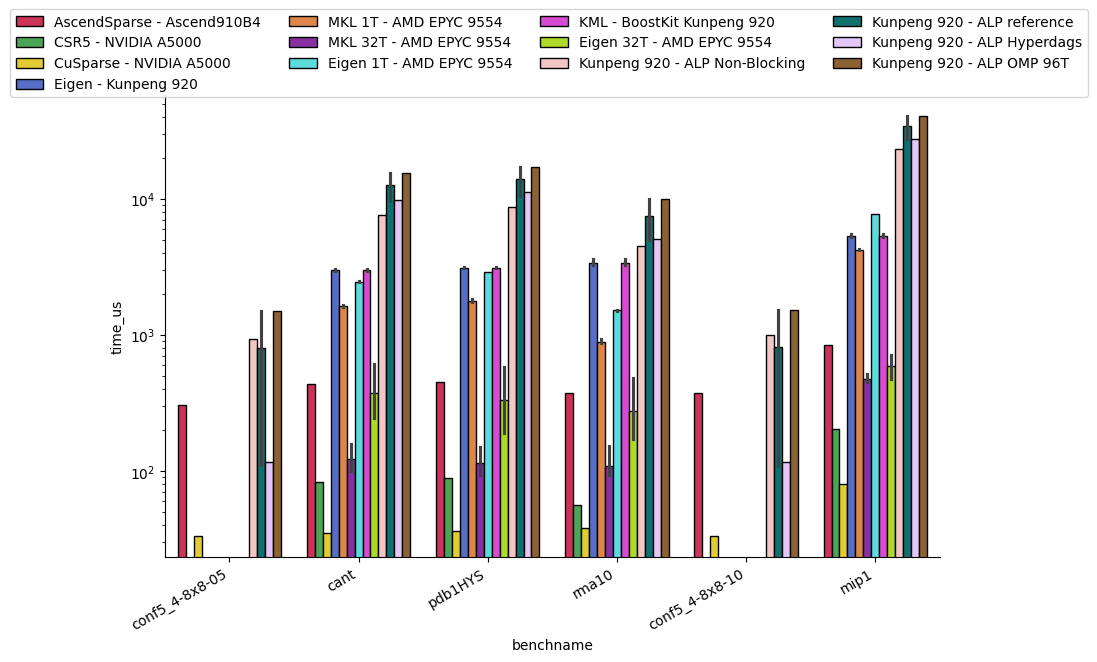

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = [
    "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231", 
    "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe", 
    "#008080", "#e6beff", "#9a6324"
]

plt.figure(figsize=(10,6))

ax = sns.barplot(data=tot_df, x="benchname", y="time_us", hue="accelerator", edgecolor="black", palette=palette)

num_accelerators = len(tot_df["accelerator"].unique()) / 3

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(bbox_to_anchor=(1.2, 1.2), ncol=int(num_accelerators))
plt.xticks(rotation=30, ha='right')
plt.yscale('log')
plt.savefig("spmv_soa_comparison.svg", bbox_inches='tight')
